<h1 align = 'center'>Practical: Data Analysis & Vectors</h1>

In [1]:
# import all necessary lib
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

<hr>

### Q1. Distance Matrix with NumPy Broadcasting

You have 3 delivery locations (group A) and 2 warehouses (group B), given as 2D coordinates:
```
A = np.array([[1, 2],
            [4, 6],
            [7, 1]])
            
B = np.array([[0, 0],
            [5, 5]])
```
1. Reshape A and B for broadcasting: A_exp = A[:, np.newaxis, :] and B_exp = B[np.newaxis, :, :] . Print both
shapes.
2. Compute the difference diff = A_exp - B_exp . Print its shape.
3. Compute the Euclidean distance matrix using places.
np.sqrt(np.sum(diff**2, axis=2)) . Print the result rounded to 2 decimal
4. In a Markdown cell, answer: which warehouse (B0 or B1) is closer on average to all delivery locations?

### ANSWER

In [2]:
A = np.array([[1, 2],[4, 6],[7, 1]])
B = np.array([[0, 0],[5, 5]])
#1
A_exp = A[:, np.newaxis, :]
B_exp = B[np.newaxis, :, :]
print(A_exp)
print()
print(B_exp)

[[[1 2]]

 [[4 6]]

 [[7 1]]]

[[[0 0]
  [5 5]]]


In [3]:
#2
diff = A_exp - B_exp
print(diff)
print()
print(diff.shape)

[[[ 1  2]
  [-4 -3]]

 [[ 4  6]
  [-1  1]]

 [[ 7  1]
  [ 2 -4]]]

(3, 2, 2)


In [4]:
#3
distance = np.sqrt(np.sum(diff**2, axis = 2))
for i in range(distance.shape[0]):
    for j in range(distance.shape[1]):
        print(round(distance[i][j], 2), end = " ")
    print()

2.24 5.0 
7.21 1.41 
7.07 4.47 


#### Answer Q1.4: B1 is closer on average ot all delivery locations.

<hr>

### Q2. Given:
p = [2, 1, -3] <br>
q = [4, -2, 1]
1. Compute p · q using four different methods (loop, np.dot, np.multiply + sum, np.matmul ).
2. Using the geometric formula p · q = ||p|| × ||q|| × cos(θ) , compute the angle θ between p and q in both
radians and degrees.
3. Interpret the angle: are the vectors more aligned, perpendicular, or opposing?
4. Now create a vector r that is guaranteed to be orthogonal to p (dot product = 0) in 3D. Verify it numerically.

### ANSWER

In [5]:
p = [2, 1, -3]
q = [4, -2, 1]

#1
#1-method
mult1 = 0
length = len(p)
for i in range(length):
    mult1 += p[i] * q[i] 
print(mult1)

#2-method
mult2 = np.dot(p, q)
print(mult2)

#3-method
mult3 = np.sum(np.multiply(p, q))
print(mult3)

#4-method
mult4 = np.matmul(p, q)
print(mult4)

3
3
3
3


In [6]:
#2
angle = math.acos(mult4 / (np.linalg.norm(p) * np.linalg.norm(q)))
print(angle)
print(math.degrees(angle))

1.3949275767021716
79.92346287144585


In [7]:
#3
#vectors are aligned/acute

In [8]:
#4
p = [2, 1, -3]
# r = ?

<hr>

### Q3. Given vectors:
u = [3, -4] <br>
v = [-6, 8]
1. Compute the magnitudes of u and v . What is the ratio ||v|| / ||u|| ? What does this ratio tell you?
2. Compute the unit vectors of u and v . What do you notice?
3. Are u and v parallel? Justify your answer mathematically (do not just plot — use the dot product and magnitudes).
4. On a single plot, draw u , v , and the unit vector of u . Add a legend and dashed axes.
## ANSWER

2.0
[ 0.6 -0.8]
[-0.6  0.8]
-1.0
180.0


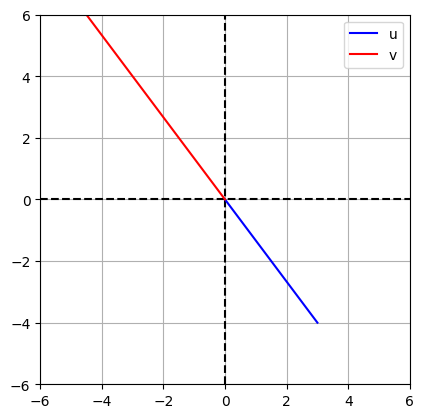

In [9]:
u = [3, -4]
v = [-6, 8]

#1
length_u = np.linalg.norm(u)
length_v = np.linalg.norm(v)
ratio = length_v/length_u
print(ratio)
#the length of v vector is twice longer than the length of u vector

#2
unit_u = u/length_u
unit_v = v/length_v
print(unit_u)
print(unit_v)
#vectors u and v are parallel

#3
prod = np.dot(u, v) / (length_u * length_v)
print(prod)
print(math.degrees(math.acos(prod)))
#cos(angle) = -1  ->  arccos(angle) = 180  ->  vectors are parallel

#4
plt.plot([-6,6], [0,0], "k--")
plt.plot([0,0], [-6,6],"k--")
plt.plot([0, u[0]], [0, u[1]], "b", label="u")
plt.plot([0, v[0]], [0, v[1]], "r", label="v")
plt.axis('square')
plt.axis(( -6, 6, -6, 6 ))
plt.legend()
plt.grid()

<hr>

### Q4. Pandas: Load, Explore & Clean
Load the MPG dataset (car fuel efficiency), a dataset built into Seaborn: <br>
df = sns.load_dataset('mpg') <br>
Each row is a car model. Key columns: mpg (miles per gallon), cylinders, weight, horsepower, origin, name. <br>
1. Print the shape and display the first 5 rows.
2. Print the number of missing values per column. Which column has missing values?
3. Create df_clean by dropping rows with any missing values using .dropna() . Print the new shape.
4. Print basic summary statistics using .describe() . What is the average mpg ?
### ANSWER

In [10]:
#1
df = sns.load_dataset('mpg')
print(df.shape)
print()
print(df.head(5))

(398, 9)

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [11]:
#2
df.isnull().sum()
#the column horsepower has missing values

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [12]:
#3
df_clean = df.dropna(axis = 0)
df_clean.shape

(392, 9)

In [13]:
#4
df_clean.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


#### Answers:
- the average mpg = 23.44

<hr>

### Q5. Filtering, Sorting & GroupBy
Using df_clean from Q2:
1. Filter cars with mpg > 30 (fuel-efficient cars). Print how many there are.
2. Sort the dataset by mpg in descending order and display the top 5 most fuel-efficient cars — show only the columns name, mpg, cylinders, origin.
4. Use GroupBy to find the average mpg per country of origin ( origin ). Print the result.
5. In one Markdown sentence, state which country produces the most fuel-efficient cars on average.

### ANSWER

In [14]:
#1
mpg_gt_30 = df_clean[df_clean['mpg'] > 30].count().iloc[0]
print(mpg_gt_30)

#2
df_clean.sort_values(by = 'mpg', ascending = False)[['name', 'mpg', 'cylinders', 'origin']].head(5)

83


,name,mpg,cylinders,origin
322,mazda glc,46.6,4,japan
329,honda civic 1500 gl,44.6,4,japan
325,vw rabbit c (diesel),44.3,4,europe
394,vw pickup,44.0,4,europe
326,vw dasher (diesel),43.4,4,europe


In [19]:
#3
avg_mpg_by_orig = df_clean.groupby('origin')['mpg'].mean().reset_index()
avg_mpg_by_orig

,origin,mpg
0,europe,27.602941
1,japan,30.450633
2,usa,20.033469


#### Answer Q3.4: Europe

<hr>

### Q6. Visualization
Using df_clean, create a figure with two subplots side by side ( figsize=(12, 4) ):
- Left subplot: A bar plot of average mpg per origin. Title: 'Average MPG by Country' . Add a y-axis label 'MPG'
- Right subplot: A scatter plot of weight (x-axis) vs mpg (y-axis). Title: 'MPG vs Car Weight'
- Add axis labels.
Use plt.tight_layout() and plt. show() . In a Markdown cell, write one observation from the scatter plot.
### ANSWER

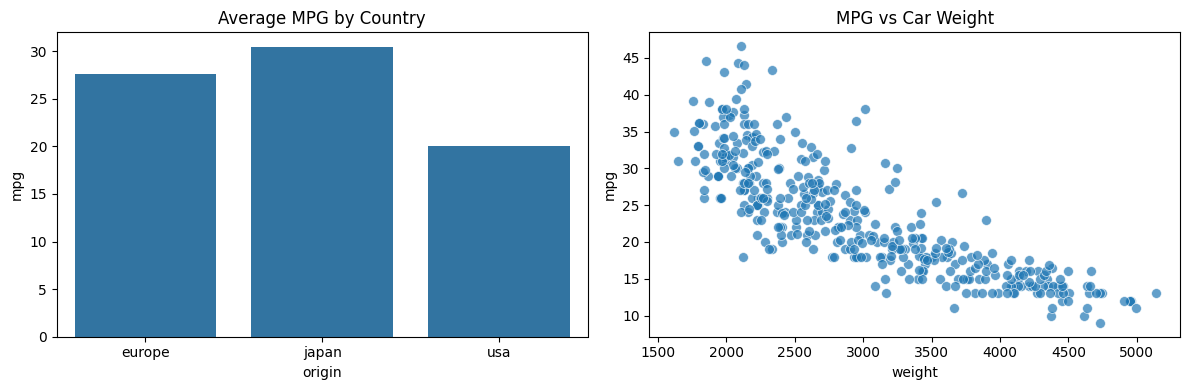

In [25]:
plt.figure(figsize = (12,4))

plt.subplot(1,2,1)
sns.barplot(x = 'origin', y = 'mpg', data = avg_mpg_by_orig)
plt.title('Average MPG by Country')

plt.subplot(1,2,2)
sns.scatterplot(x = 'weight', y = 'mpg', data = df_clean, alpha = 0.7, s = 50)
plt.title('MPG vs Car Weight')

plt.tight_layout()
plt.show()

#### Observation: Heavier cars tend to have lower fuel efficiency.

<hr>

### Q7. KNN Classification on the Wine Dataset
The Wine dataset contains chemical measurements of wines from 3 different cultivars (classes 0, 1, 2). It is loaded from sklearn.
1. Load the dataset and print feature_names, target_names , and the shape of the data.
2. Split into train/test sets (75% train, 25% test) using random_state=42.
3. Train a KNeighborsClassifier with n_neighbors=5 . Print the test accuracy.
4. In a Markdown cell, state in one sentence whether this is a classification or regression problem and why.
### ANSWER

In [48]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#1
wine = load_wine()
print(wine.feature_names)
print(wine.target_names)
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
print(df.shape)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']
(178, 14)


In [42]:
#2
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size = 0.25, random_state = 42, stratify = wine.target)

In [47]:
#3
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
accuracy_score(y_pred, y_test)

0.7777777777777778

#### Answer Q7.4: This is a classification problem because the target variable represents discrete classes (wine cultivars), not continuous values.